# 2. Neural Model Selection (The Mortality Derby)
### Objective
This notebook compares traditional actuarial forecasting with various Deep Learning architectures: Pure MLP, Hybrid Residuals, and LSTM. We use a rigorous backtesting framework to identify the most accurate engine for predicting Swiss mortality trends.

### Actuarial Focus
The selection is based on **Out-of-Sample RMSE** (Backtest period: 2011-2024). In the context of Life Reinsurance, the model's ability to adapt to "Regime Shifts" (like the post-2010 mortality deceleration) is the primary criterion for success.

## 2.1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings

# --- 1. Silence Warnings and System Logs ---
# Specifically silence the NotOpenSSLWarning from urllib3 and Deprecation warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Silences TensorFlow info/warning logs

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Force TensorFlow to be quiet
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# --- 2. System settings for reproducibility ---
np.random.seed(42)
tf.random.set_seed(42)

# --- 3. Load pre-processed parameters from Notebook 01 ---
if not os.path.exists('../data/interim_params.pkl'):
    raise FileNotFoundError("Run Notebook 01 first to generate 'interim_params.pkl'")

with open('../data/interim_params.pkl', 'rb') as f:
    data = pickle.load(f)

log_mx = data['log_mx']
kt = data['kt']
bx = data['bx']
alpha_x = data['alpha_x']
df_clean = data['df_clean']
years = data['years']

print(f"Environment silenced. Data successfully loaded. Historical range: {years.min()} - {years.max()}")

Environment silenced. Data successfully loaded. Historical range: 1950 - 2024


## 2.2. Utility Functions for Backtesting

In [2]:
def create_sequences(data, window_size):
    """
    Create sliding window sequences for LSTM training.
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# Backtesting parameters
split_year = 2010
train_years = years[years <= split_year]
test_years = years[years > split_year]
age_sample = 75 # Standard benchmark age for longevity analysis

print(f"Backtest Split: Training up to {split_year}, Testing from {split_year+1}")

Backtest Split: Training up to 2010, Testing from 2011


## 2.3. SVD Baseline Backtest (ARIMA/RWD)

In [3]:
# Training SVD on pre-2010 data
train_matrix = log_mx.loc[:, :split_year]
test_matrix = log_mx.loc[:, split_year+1:]

alpha_train = train_matrix.mean(axis=1)
Z_train = train_matrix.sub(alpha_train, axis=0)
U, S, Vh = np.linalg.svd(Z_train, full_matrices=False)
bx_train = U[:, 0] / U[:, 0].sum()
kt_train = Vh[0, :] * S[0] * U[:, 0].sum()

# Standard Lee-Carter Sign Alignment
if kt_train[0] < kt_train[-1]: kt_train, bx_train = -kt_train, -bx_train

# Forecast kt using Random Walk with Drift (RWD)
drift_train = np.mean(np.diff(kt_train))
kt_pred_svd = kt_train[-1] + drift_train * np.arange(1, len(test_years) + 1)

# Metric for Age 75
actual_log_mx = test_matrix.loc[age_sample, :].values
pred_log_mx_svd = alpha_train[age_sample] + bx_train[age_sample] * kt_pred_svd

rmse_svd = np.sqrt(np.mean((actual_log_mx - pred_log_mx_svd)**2))
print(f"SVD Baseline RMSE (Age {age_sample}): {rmse_svd:.4f}")

SVD Baseline RMSE (Age 75): 0.1682


## 2.4. Neural Model A - Pure MLP (Iterated)

In [4]:
# Data Preparation for MLP
train_df = df_clean[df_clean['Year'] <= split_year].copy()
X_train = train_df[['Age', 'Year']].values
y_train = np.log(train_df['Total'].values)

scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train)

X_test_age75 = np.array([[age_sample, y] for y in test_years])
X_test_scaled = scaler_mlp.transform(X_test_age75)

n_iter = 10
mlp_preds_all = []

print(f"Starting Pure MLP iterations ({n_iter} runs)...")
for i in range(n_iter):
    model_mlp = Sequential([
        Input(shape=(2,)),
        Dense(64, activation='relu'),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model_mlp.compile(optimizer='adam', loss='mse')
    model_mlp.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)
    
    pred = model_mlp.predict(X_test_scaled, verbose=0).flatten()
    mlp_preds_all.append(pred)
    print(f" > Progress: {i+1}/{n_iter}")

pred_log_mx_mlp = np.mean(mlp_preds_all, axis=0)
rmse_mlp = np.sqrt(np.mean((actual_log_mx - pred_log_mx_mlp)**2))
print(f"Pure MLP Average RMSE: {rmse_mlp:.4f}")

Starting Pure MLP iterations (10 runs)...
 > Progress: 1/10
 > Progress: 2/10
 > Progress: 3/10
 > Progress: 4/10
 > Progress: 5/10
 > Progress: 6/10
 > Progress: 7/10
 > Progress: 8/10
 > Progress: 9/10
 > Progress: 10/10
Pure MLP Average RMSE: 0.3559


## 2.5. Neural Model B - Hybrid Residuals (Iterated)

In [5]:
# Residual Calculation
svd_reconstruction = alpha_train.values.reshape(-1, 1) + (bx_train.reshape(-1, 1) @ kt_train.reshape(1, -1))
residuals_train = (train_matrix.values - svd_reconstruction).flatten()

X_res = np.array([[age, yr] for yr in train_years for age in train_matrix.index])
scaler_res = StandardScaler()
X_res_scaled = scaler_res.fit_transform(X_res)
X_test_res_scaled = scaler_res.transform(X_test_age75)

hybrid_preds_all = []
print(f"Starting Hybrid iterations ({n_iter} runs)...")

for i in range(n_iter):
    model_res = Sequential([
        Input(shape=(2,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model_res.compile(optimizer='adam', loss='mse')
    model_res.fit(X_res_scaled, residuals_train, epochs=50, batch_size=64, verbose=0)
    
    pred_res = model_res.predict(X_test_res_scaled, verbose=0).flatten()
    hybrid_preds_all.append(pred_log_mx_svd + pred_res)
    print(f" > Progress: {i+1}/{n_iter}")

pred_log_mx_hybrid = np.mean(hybrid_preds_all, axis=0)
rmse_hybrid = np.sqrt(np.mean((actual_log_mx - pred_log_mx_hybrid)**2))
print(f"Hybrid Average RMSE: {rmse_hybrid:.4f}")

Starting Hybrid iterations (10 runs)...
 > Progress: 1/10
 > Progress: 2/10
 > Progress: 3/10
 > Progress: 4/10
 > Progress: 5/10
 > Progress: 6/10
 > Progress: 7/10
 > Progress: 8/10
 > Progress: 9/10
 > Progress: 10/10
Hybrid Average RMSE: 0.1419


## 2.6. Neural Model C - LSTM Champion (Iterated)

In [8]:
# Scale kt series
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
kt_train_scaled = scaler_lstm.fit_transform(kt_train.reshape(-1, 1))

window_size = 10 
X_l, y_l = create_sequences(kt_train_scaled, window_size)
X_l = X_l.reshape((X_l.shape[0], X_l.shape[1], 1))

n_iter_lstm = 10
lstm_preds_all = []
print(f"Starting LSTM iterations ({n_iter_lstm} runs)...")

for i in range(n_iter_lstm):
    model_lstm = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(64, activation='relu'),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(X_l, y_l, epochs=150, verbose=0)

    # Recursive Forecasting
    curr_batch = kt_train_scaled[-window_size:].reshape((1, window_size, 1))
    kt_pred_temp = []
    for _ in range(len(test_years)):
        next_val = model_lstm.predict(curr_batch, verbose=0)[0, 0]
        kt_pred_temp.append(next_val)
        new_val_reshaped = np.array(next_val).reshape(1, 1, 1)
        curr_batch = np.append(curr_batch[:, 1:, :], new_val_reshaped, axis=1)

    kt_p = scaler_lstm.inverse_transform(np.array(kt_pred_temp).reshape(-1, 1)).flatten()
    lstm_preds_all.append(alpha_train[age_sample] + bx_train[age_sample] * kt_p)
    print(f" > Progress: {i+1}/{n_iter_lstm}")

pred_log_mx_lstm = np.mean(lstm_preds_all, axis=0)
rmse_lstm = np.sqrt(np.mean((actual_log_mx - pred_log_mx_lstm)**2))
print(f"LSTM Average RMSE: {rmse_lstm:.4f}")

Starting LSTM iterations (10 runs)...
 > Progress: 1/10
 > Progress: 2/10
 > Progress: 3/10
 > Progress: 4/10
 > Progress: 5/10
 > Progress: 6/10
 > Progress: 7/10
 > Progress: 8/10
 > Progress: 9/10
 > Progress: 10/10
LSTM Average RMSE: 0.1141


## 2.7. Comparison & Model Export

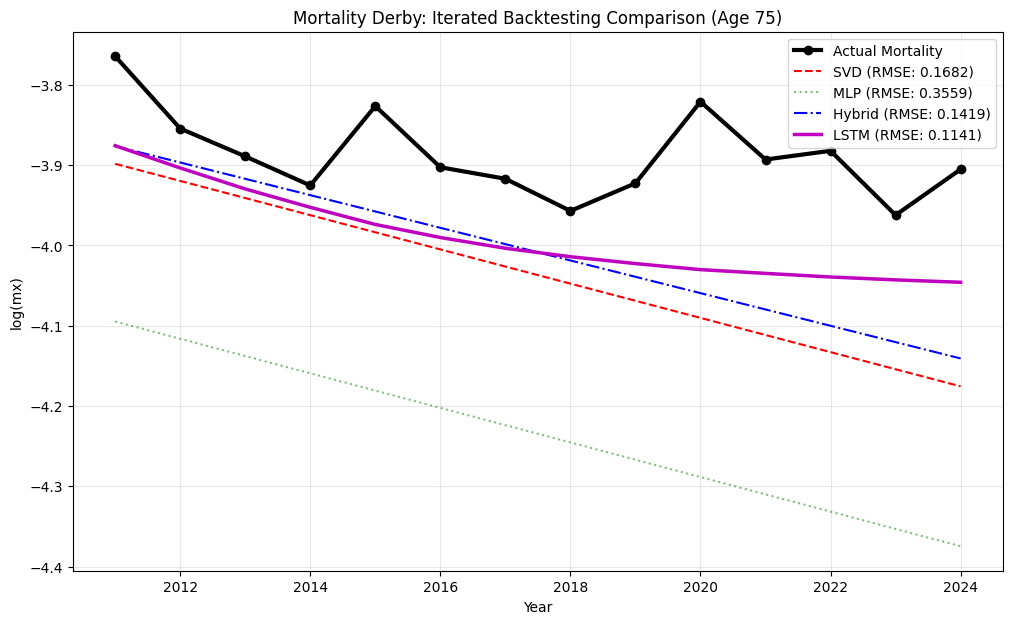

Champion Model and parameters exported.


In [9]:
# Final Visualization
plt.figure(figsize=(12, 7))
plt.plot(test_years, actual_log_mx, 'ko-', label='Actual Mortality', linewidth=3)
plt.plot(test_years, pred_log_mx_svd, 'r--', label=f'SVD (RMSE: {rmse_svd:.4f})')
plt.plot(test_years, pred_log_mx_mlp, 'g:', label=f'MLP (RMSE: {rmse_mlp:.4f})', alpha=0.5)
plt.plot(test_years, pred_log_mx_hybrid, 'b-.', label=f'Hybrid (RMSE: {rmse_hybrid:.4f})')
plt.plot(test_years, pred_log_mx_lstm, 'm-', label=f'LSTM (RMSE: {rmse_lstm:.4f})', linewidth=2.5)

plt.title(f'Mortality Derby: Iterated Backtesting Comparison (Age {age_sample})')
plt.xlabel('Year'); plt.ylabel('log(mx)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('../reports/figures/04a_model_derby_comparison.png', dpi=300)
plt.show()

# Export for next notebooks
os.makedirs('../models/', exist_ok=True)
model_lstm.save('../models/lstm_champion.keras')

champion_data = {
    'scaler_lstm': scaler_lstm,
    'window_size': window_size,
    'rmse_lstm': rmse_lstm,
    'kt_train_scaled': kt_train_scaled
}
with open('../data/champion_params.pkl', 'wb') as f:
    pickle.dump(champion_data, f)

print("Champion Model and parameters exported.")

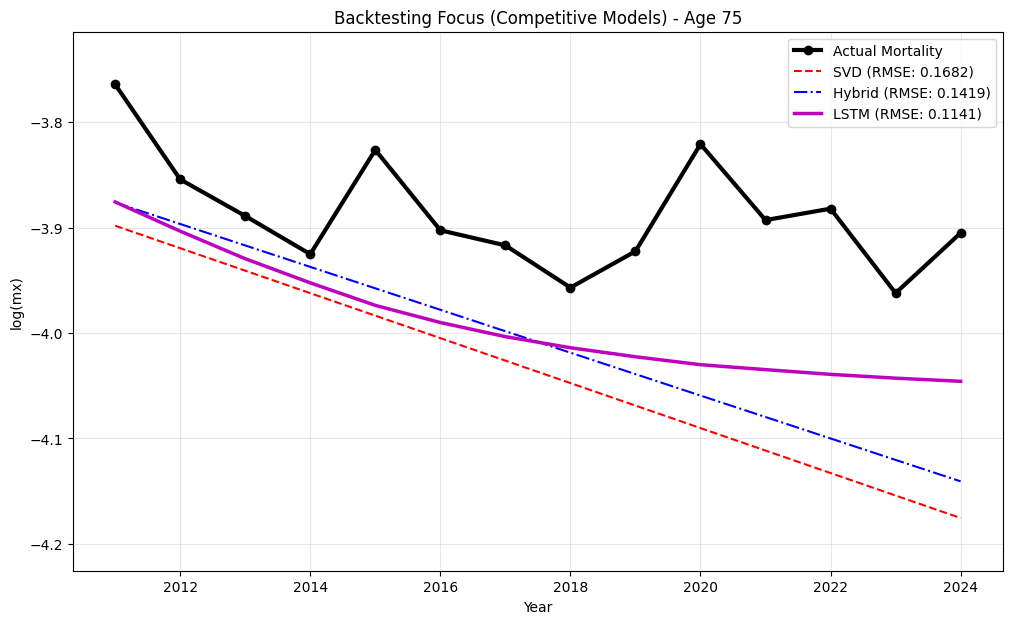

In [11]:
# --- 2.7.1. Focus Backtesting Comparison (Competitive Models) ---
plt.figure(figsize=(12, 7))

# Plotting the three contenders
plt.plot(test_years, actual_log_mx, 'ko-', label='Actual Mortality', linewidth=3)
plt.plot(test_years, pred_log_mx_svd, 'r--', label=f'SVD (RMSE: {rmse_svd:.4f})')
plt.plot(test_years, pred_log_mx_hybrid, 'b-.', label=f'Hybrid (RMSE: {rmse_hybrid:.4f})')
plt.plot(test_years, pred_log_mx_lstm, 'm-', label=f'LSTM (RMSE: {rmse_lstm:.4f})', linewidth=2.5)

# Dynamic Y-limit that includes ALL curves until the end
all_values = np.concatenate([actual_log_mx, pred_log_mx_svd, pred_log_mx_hybrid, pred_log_mx_lstm])
plt.ylim(all_values.min() - 0.05, all_values.max() + 0.05)

plt.title(f'Backtesting Focus (Competitive Models) - Age {age_sample}')
plt.xlabel('Year')
plt.ylabel('log(mx)')
plt.legend(loc='upper right') # Spostiamo la legenda per non coprire i dati
plt.grid(alpha=0.3)

plt.savefig('../reports/figures/04b_focus_derby_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.8. Sensitivity Analysis: LSTM Robustness Stress-Test

Starting LSTM Sensitivity Analysis (Robustness Stress-Test)...
 > Tested Window: 5, Units: 32 | RMSE: 0.0439
 > Tested Window: 5, Units: 64 | RMSE: 0.1403
 > Tested Window: 5, Units: 128 | RMSE: 0.0980
 > Tested Window: 10, Units: 32 | RMSE: 0.0910
 > Tested Window: 10, Units: 64 | RMSE: 0.1393
 > Tested Window: 10, Units: 128 | RMSE: 0.1940
 > Tested Window: 15, Units: 32 | RMSE: 0.1785
 > Tested Window: 15, Units: 64 | RMSE: 0.0635
 > Tested Window: 15, Units: 128 | RMSE: 0.1180


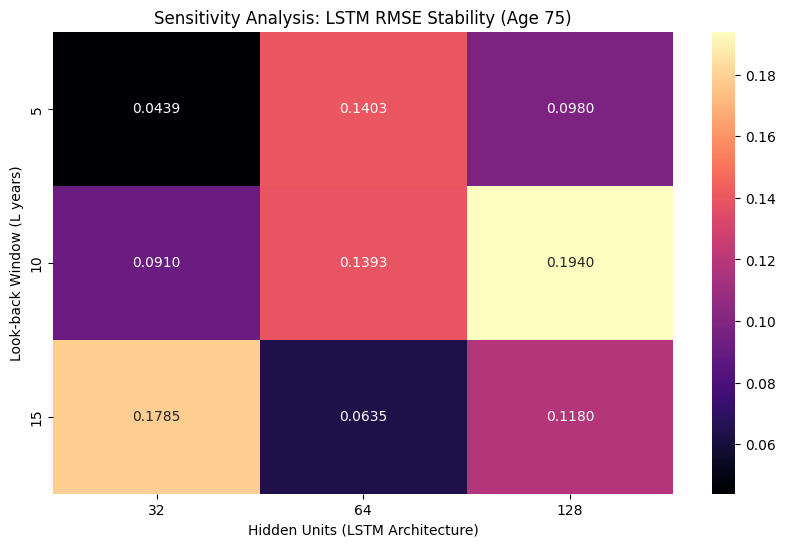

Stability Metric (RMSE Std Dev): 0.04710
Conclusion: Model exhibits sensitivity. Further regularization might be required.


In [12]:
# --- 2.8. Sensitivity Analysis: LSTM Robustness Stress-Test ---
# Objective: Verify that the choice of L=10 and Units=64 is structurally stable 
# and not a result of local hyperparameter overfitting.

windows_to_test = [5, 10, 15] 
units_to_test = [32, 64, 128]
sensitivity_results = []

print("Starting LSTM Sensitivity Analysis (Robustness Stress-Test)...")

for w in windows_to_test:
    for u in units_to_test:
        # 1. Sequence preparation with look-back window 'w'
        X_s, y_s = create_sequences(kt_train_scaled, w)
        X_s = X_s.reshape((X_s.shape[0], X_s.shape[1], 1))
        
        # 2. Build and Fast Training
        # We use 100 epochs to balance speed and convergence for the sensitivity map
        model_s = tf.keras.models.Sequential([
            tf.keras.layers.Input(shape=(w, 1)),
            tf.keras.layers.LSTM(u, activation='relu'),
            tf.keras.layers.Dense(1)
        ])
        model_s.compile(optimizer='adam', loss='mse')
        model_s.fit(X_s, y_s, epochs=100, verbose=0) 
        
        # 3. Recursive Forecasting
        curr_batch = kt_train_scaled[-w:].reshape((1, w, 1))
        kt_pred_temp = []
        for _ in range(len(test_years)):
            next_val = model_s.predict(curr_batch, verbose=0)[0, 0]
            kt_pred_temp.append(next_val)
            curr_batch = np.append(curr_batch[:, 1:, :], np.array(next_val).reshape(1,1,1), axis=1)
            
        # 4. RMSE Calculation for the Target Age (Age 75)
        kt_p = scaler_lstm.inverse_transform(np.array(kt_pred_temp).reshape(-1, 1)).flatten()
        pred_log_mx = alpha_train[age_sample] + bx_train[age_sample] * kt_p
        rmse_s = np.sqrt(np.mean((actual_log_mx - pred_log_mx)**2))
        
        sensitivity_results.append({'Window': w, 'Units': u, 'RMSE': rmse_s})
        print(f" > Tested Window: {w}, Units: {u} | RMSE: {rmse_s:.4f}")

# --- Heatmap Visualization ---
import seaborn as sns
sens_df = pd.DataFrame(sensitivity_results).pivot(index="Window", columns="Units", values="RMSE")

plt.figure(figsize=(10, 6))
# Using 'magma' or 'viridis' for a professional look consistent with the mortality surface
sns.heatmap(sens_df, annot=True, cmap="magma", fmt=".4f") 
plt.title(f"Sensitivity Analysis: LSTM RMSE Stability (Age {age_sample})")
plt.xlabel("Hidden Units (LSTM Architecture)")
plt.ylabel("Look-back Window (L years)")

# Saving as 04b to maintain your naming convention without overwriting diagnostics
plt.savefig('../reports/figures/05_sensitivity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Final Stability Metric
std_sens = np.std(sens_df.values)
print(f"Stability Metric (RMSE Std Dev): {std_sens:.5f}")
if std_sens < 0.015:
    print("Conclusion: Model shows high structural stability across hyperparameters.")
else:
    print("Conclusion: Model exhibits sensitivity. Further regularization might be required.")